# The Diversification Tax
### Project 2 — The Diversification Series

Traditional diversification optimizes the appearance of control, not risk/return.  
You pay a permanent carry cost for inconsistent protection — and a simple rule delivers more with less.

**Three portfolios:**
- **Diversified** — 60% SPY + 13.3% TLT + 13.3% IEF + 13.3% GLD | annual rebalance
- **SPY Buy & Hold** — 100% SPY | benchmark anchor
- **MA200 Filter** — 100% SPY above MA200 / 50% SPY + 50% cash below MA200

**Two datasets:**
- `ret_b.csv` — SPY, EFA, EEM, TLT, IEF, GLD, DBC | 2006–2024 | main analysis
- `ret_a.csv` — SPX, Treasury, DXY | 1980–2024 | historical context

**Stress regime:** inherited from Project 1 algorithmic episode detection — same parameters, applied consistently.

---
*No look-ahead bias. MA200 shifted 1 day. Cash return = 0 when MA200 filter is out of market.*

In [1]:
# ── Imports & configuration ─────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

print("✓ Imports OK")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")

✓ Imports OK
  pandas  : 2.3.3
  numpy   : 2.4.0


In [2]:
# ── Parameters ───────────────────────────────────────────────────────

# ── Date ranges ───────────────────────────────────────────────────────────────
START_B = "2006-01-01"
START_A = "1980-01-01"
END     = "2026-04-16"

# ── Diversified portfolio weights ─────────────────────────────────────────────
# Weights sum exactly to 1.0
# 60% equity / 40% defensive (equal-weight across TLT, IEF, GLD)
_def_w = (1 - 0.60) / 3  # = 0.1333...
DIVERSIFIED_WEIGHTS = {
    "SPY": 0.60,
    "TLT": _def_w,
    "IEF": _def_w,
    "GLD": _def_w,
}

# ── MA200 Filter ──────────────────────────────────────────────────────────────
MA200_WINDOW      = 200   # days
MA200_SHIFT       = 1     # 1-day shift — no look-ahead
MA200_BELOW_SPY   = 0.50  # SPY exposure when below MA200
MA200_CASH_RETURN = 0.00  # cash return when out of market (conservative assumption)
                           # prices include reinvested dividends (yfinance auto_adjust=True)
                           # cash earns zero — any real cash return would favor MA200 further

# ── Episode detection — inherited from P1, identical parameters ───────────────
ROLL_THRESH    = 252
ALGO_DD_START  = 0.15
ALGO_DD_END    = 0.20
ALGO_RECOVERY  = 0.075

print("✓ Parameters set")
print(f"  Diversified weights  : {DIVERSIFIED_WEIGHTS}")
print(f"  MA200 window         : {MA200_WINDOW} days | shift : {MA200_SHIFT} day")
print(f"  MA200 below exposure : {MA200_BELOW_SPY:.0%} SPY + {1-MA200_BELOW_SPY:.0%} cash")
print(f"  Cash return          : {MA200_CASH_RETURN:.0%} (conservative — dividends included via auto_adjust)")
print(f"  Algo DD start        : {ALGO_DD_START:.0%}")
print(f"  Algo DD end          : {ALGO_DD_END:.0%}")
print(f"  Algo recovery        : {ALGO_RECOVERY:.1%}")

✓ Parameters set
  Diversified weights  : {'SPY': 0.6, 'TLT': 0.13333333333333333, 'IEF': 0.13333333333333333, 'GLD': 0.13333333333333333}
  MA200 window         : 200 days | shift : 1 day
  MA200 below exposure : 50% SPY + 50% cash
  Cash return          : 0% (conservative — dividends included via auto_adjust)
  Algo DD start        : 15%
  Algo DD end          : 20%
  Algo recovery        : 7.5%


In [3]:
# ── Load data (from saved CSVs) ─────────────────────────────────────
import os

FILE_B = "../data/ret_b.csv"
FILE_A = "../data/ret_a.csv"

if os.path.exists(FILE_B) and os.path.exists(FILE_A):
    ret_b = pd.read_csv(FILE_B, index_col=0, parse_dates=True)
    ret_a = pd.read_csv(FILE_A, index_col=0, parse_dates=True)
    ret_b = ret_b.sort_index()
    ret_a = ret_a.sort_index()
    print("✓ Loaded from saved CSVs")
else:
    import yfinance as yf
    import pandas_datareader.data as web

    DURATION_APPROX = 8.5

    prices_b_raw = yf.download(
        ["SPY","EFA","EEM","TLT","IEF","GLD","DBC"],
        start=START_B, end=END, auto_adjust=True, progress=False
    )["Close"]
    if isinstance(prices_b_raw.columns, pd.MultiIndex):
        prices_b_raw.columns = prices_b_raw.columns.get_level_values(0)
    ret_b = prices_b_raw.pct_change().dropna(how="any")

    spx_raw      = yf.download("^GSPC", start=START_A, end=END, auto_adjust=True, progress=False)["Close"]
    spx_ret      = spx_raw.pct_change().dropna()
    spx_ret.name = "SPX"

    dgs10_raw    = web.DataReader("DGS10", "fred", START_A, END)["DGS10"].dropna()
    dgs10_raw.index = pd.to_datetime(dgs10_raw.index)
    treasury_ret = (-DURATION_APPROX * dgs10_raw.diff() / 100).dropna()
    treasury_ret.name = "Treasury"

    dxy_raw      = yf.download("DX-Y.NYB", start=START_A, end=END, auto_adjust=True, progress=False)["Close"]
    dxy_ret      = dxy_raw.pct_change().dropna()
    dxy_ret.name = "DXY"

    ret_a = pd.concat([spx_ret, treasury_ret, dxy_ret], axis=1).dropna(how="any")

    os.makedirs("data", exist_ok=True)
    ret_b.to_csv(FILE_B)
    ret_a.to_csv(FILE_A)
    print("✓ Downloaded and saved")

print(f"  ret_b: {ret_b.index[0].date()} → {ret_b.index[-1].date()} | {len(ret_b)} obs")
print(f"  ret_a: {ret_a.index[0].date()} → {ret_a.index[-1].date()} | {len(ret_a)} obs")

✓ Loaded from saved CSVs
  ret_b: 2006-02-07 → 2026-04-16 | 5079 obs
  ret_a: 1980-01-03 → 2026-04-16 | 11558 obs


## 1. Data & Infrastructure

In [4]:
# ── Price series & MA200 ────────────────────────────────────────────

# ── Cumulative wealth index from returns (base = 1) ───────────────────────────
# Note: this is a reconstructed wealth index, not original price series
wealth_b = (1 + ret_b).cumprod()
wealth_a = (1 + ret_a).cumprod()

# ── SPY MA200 (shifted 1 day — no look-ahead) ─────────────────────────────────
spy_ma200 = wealth_b["SPY"].rolling(MA200_WINDOW).mean().shift(MA200_SHIFT)

# ── MA200 signal : 1 = above (full exposure), 0 = below (half exposure) ───────
# NaN during warmup period (first 200 days) → excluded from all analysis
ma200_signal = (wealth_b["SPY"] > spy_ma200).astype(float)  # float to allow NaN
ma200_signal[spy_ma200.isna()] = np.nan  # explicit NaN during warmup

# ── Warmup cutoff date ────────────────────────────────────────────────────────
warmup_cutoff = spy_ma200.first_valid_index()

# ── Sanity check ──────────────────────────────────────────────────────────────
total      = ma200_signal.dropna().shape[0]
days_above = (ma200_signal == 1).sum()
days_below = (ma200_signal == 0).sum()

print("── Wealth index ───────────────────────────────────────────")
print(f"  wealth_b shape : {wealth_b.shape}")
print(f"  wealth_a shape : {wealth_a.shape}")
print()
print("── MA200 (SPY) ────────────────────────────────────────────")
print(f"  Warmup cutoff    : {warmup_cutoff.date()} (first {MA200_WINDOW} days excluded)")
print(f"  Days above MA200 : {days_above} ({days_above/total:.1%})")
print(f"  Days below MA200 : {days_below} ({days_below/total:.1%})")
print(f"  NaNs (warmup)    : {ma200_signal.isna().sum()}")

── Wealth index ───────────────────────────────────────────
  wealth_b shape : (5079, 7)
  wealth_a shape : (11558, 3)

── MA200 (SPY) ────────────────────────────────────────────
  Warmup cutoff    : 2006-11-21 (first 200 days excluded)
  Days above MA200 : 3839 (78.7%)
  Days below MA200 : 1040 (21.3%)
  NaNs (warmup)    : 200


## 2. Stress Episode Detection
*Inherited from Project 1 — identical algorithm and parameters. Regime definition is consistent across the series.*

**Data extension note:** Project 1 covered 2006–2024. Project 2 extends to April 2026 using the same
algorithm and identical parameters. Two additional episodes were detected with the extended data:
Episode 8 (Banking Stress, March 2023) and Episode 9 (2025 selloff). These are not redefinitions —
they are the same detector running on more data.

**Data note:** Historical context sample (1980–2026) uses a Treasury return proxy
constructed from 10-year yield changes × duration approximation (8.5y).
This is not an investable total return series — it is used for structural
correlation analysis only, not performance comparison.

In [5]:
# ── Episode detection (inherited from P1) ───────────────────────────

def detect_stress_episodes(ret_series, price_series,
                            dd_start=ALGO_DD_START,
                            dd_end=ALGO_DD_END,
                            recovery=ALGO_RECOVERY):
    """
    Detect stress episodes algorithmically.
    Entry : drawdown from rolling 252-day peak < -dd_start AND price < MA200
    Exit  : price > MA200 AND drawdown condition met
    Returns list of (start_date, end_date) tuples.
    """
    level        = (1 + ret_series).cumprod()
    rolling_peak = level.rolling(window=ROLL_THRESH, min_periods=1).max()
    drawdown     = (level - rolling_peak) / rolling_peak
    ma200        = price_series.rolling(200).mean().shift(1)

    in_episode  = False
    episodes    = []
    start_date  = None
    dd_at_entry = None

    for date in drawdown.index:
        dd = drawdown.loc[date]
        px = price_series.loc[date] if date in price_series.index else np.nan
        ma = ma200.loc[date]        if date in ma200.index        else np.nan

        if np.isnan(dd) or np.isnan(px) or np.isnan(ma):
            continue

        if not in_episode:
            if dd < -dd_start and px < ma:
                in_episode  = True
                start_date  = date
                dd_at_entry = dd
        else:
            if px > ma:
                if dd_at_entry < -dd_end:
                    exit_ok = dd > -dd_end
                else:
                    exit_ok = dd > (dd_at_entry + recovery)
                if exit_ok:
                    episodes.append((start_date, date))
                    in_episode  = False
                    start_date  = None
                    dd_at_entry = None

    if in_episode:
        episodes.append((start_date, drawdown.index[-1]))

    return episodes


# ── Run on SPY ────────────────────────────────────────────────────────────────
episodes_b  = detect_stress_episodes(ret_b["SPY"], wealth_b["SPY"])

stress_mask = pd.Series(False, index=ret_b.index)
for start, end in episodes_b:
    stress_mask.loc[start:end] = True
normal_mask = ~stress_mask

# ── Summary ───────────────────────────────────────────────────────────────────
print("── Stress episodes detected (Block B / SPY) ───────────────")
for i, (s, e) in enumerate(episodes_b):
    print(f"  Episode {i+1} : {s.date()} → {e.date()} | {(e-s).days} days")
print()
print(f"  Total stress days  : {stress_mask.sum()} ({stress_mask.sum()/len(stress_mask):.1%})")
print(f"  Total normal days  : {normal_mask.sum()} ({normal_mask.sum()/len(normal_mask):.1%})")

── Stress episodes detected (Block B / SPY) ───────────────
  Episode 1 : 2008-01-18 → 2008-05-19 | 122 days
  Episode 2 : 2008-06-26 → 2009-09-22 | 453 days
  Episode 3 : 2010-07-01 → 2010-08-02 | 32 days
  Episode 4 : 2011-08-08 → 2011-10-27 | 80 days
  Episode 5 : 2018-12-20 → 2019-02-04 | 46 days
  Episode 6 : 2020-03-09 → 2020-05-26 | 78 days
  Episode 7 : 2022-05-09 → 2023-02-02 | 269 days
  Episode 8 : 2023-03-10 → 2023-04-06 | 27 days
  Episode 9 : 2025-04-04 → 2025-05-12 | 38 days

  Total stress days  : 794 (15.6%)
  Total normal days  : 4285 (84.4%)


## 3. Portfolio Construction

In [6]:
# ── Portfolio construction ──────────────────────────────────────────

# ── 1. SPY Buy & Hold ─────────────────────────────────────────────────────────
ret_bh = ret_b["SPY"].copy()
ret_bh.name = "SPY_BH"

# ── 2. MA200 Filter ───────────────────────────────────────────────────────────
# Above MA200 : 100% SPY
# Below MA200 : 50% SPY + 50% cash (return = 0)
# Warmup period (NaN signal) : excluded via dropna downstream
ret_ma200 = (
    ma200_signal * ret_b["SPY"] +
    (1 - ma200_signal) * MA200_BELOW_SPY * ret_b["SPY"]
)
ret_ma200.name = "MA200_Filter"

# ── 3. Diversified — annual rebalance ─────────────────────────────────────────
assets  = list(DIVERSIFIED_WEIGHTS.keys())
weights = np.array(list(DIVERSIFIED_WEIGHTS.values()))

rebal_dates = (
    ret_b[assets]
    .groupby(ret_b[assets].index.year)
    .apply(lambda x: x.index[0])
    .values
)

port_div_returns = []
current_weights  = weights.copy()

for i, date in enumerate(ret_b[assets].index):
    if date in rebal_dates:
        current_weights = weights.copy()

    daily_ret = (current_weights * ret_b[assets].loc[date].values).sum()
    port_div_returns.append(daily_ret)

    current_weights = current_weights * (1 + ret_b[assets].loc[date].values)
    current_weights = current_weights / current_weights.sum()

ret_div = pd.Series(port_div_returns, index=ret_b[assets].index, name="Diversified")

# ── Combine — align to warmup cutoff ─────────────────────────────────────────
portfolios = pd.DataFrame({
    "SPY_BH"      : ret_bh,
    "MA200_Filter": ret_ma200,
    "Diversified" : ret_div,
}).loc[warmup_cutoff:]

# ── Sanity check ──────────────────────────────────────────────────────────────
print("── Portfolio returns ──────────────────────────────────────")
print(f"  Shape   : {portfolios.shape}")
print(f"  Period  : {portfolios.index[0].date()} → {portfolios.index[-1].date()}")
print(f"  NaNs    : {portfolios.isna().sum().sum()}")
print()
print(portfolios.describe().round(4))

── Portfolio returns ──────────────────────────────────────
  Shape   : (4879, 3)
  Period  : 2006-11-21 → 2026-04-16
  NaNs    : 0

         SPY_BH  MA200_Filter  Diversified
count 4879.0000     4879.0000    4879.0000
mean     0.0005        0.0006       0.0004
std      0.0124        0.0089       0.0070
min     -0.1094       -0.0576      -0.0563
25%     -0.0041       -0.0036      -0.0027
50%      0.0007        0.0006       0.0007
75%      0.0060        0.0054       0.0039
max      0.1452        0.0726       0.0636


In [7]:
# ── MA200 signal audit ──────────────────────────────────────────────
# Report false signals (whipsaws) — days MA200 was out of market with SPY rising

# Transitions: 1→0 = exit signal, 0→1 = re-entry signal
signal_changes = ma200_signal.diff().fillna(0)
exits          = signal_changes[signal_changes == -1].index  # above→below
entries        = signal_changes[signal_changes ==  1].index  # below→above

whipsaw_costs = []
for entry in entries:
    # Find the preceding exit
    prior_exits = exits[exits < entry]
    if len(prior_exits) == 0:
        continue
    last_exit = prior_exits[-1]

    # SPY return during out-of-market period (at 50% exposure)
    out_period   = ret_b["SPY"].loc[last_exit:entry]
    spy_cum      = (1 + out_period).prod() - 1
    ma200_cum    = (1 + ret_ma200.loc[last_exit:entry]).prod() - 1
    whipsaw_costs.append({
        "exit"      : last_exit.date(),
        "entry"     : entry.date(),
        "days_out"  : (entry - last_exit).days,
        "spy_ret"   : spy_cum,
        "ma200_ret" : ma200_cum,
        "cost"      : ma200_cum - spy_cum,
    })

wdf = pd.DataFrame(whipsaw_costs)

print("── MA200 signal audit ─────────────────────────────────────")
print(f"  Total exit signals   : {len(exits)}")
print(f"  Total entry signals  : {len(entries)}")
print(f"  Roundtrips tracked   : {len(wdf)}")
print()
print("  Top 10 costliest periods (MA200 out, SPY up):")
print(
    wdf.sort_values("cost")
    .head(10)
    .to_string(index=False)
)
print()
print(f"  Total drag from all out-of-market periods : {wdf['cost'].sum():.4f}")

── MA200 signal audit ─────────────────────────────────────
  Total exit signals   : 55
  Total entry signals  : 55
  Roundtrips tracked   : 55

  Top 10 costliest periods (MA200 out, SPY up):
      exit      entry  days_out  spy_ret  ma200_ret    cost
2026-03-20 2026-04-08        19   0.0274     0.0267 -0.0007
2007-08-20 2007-08-21         1   0.0015     0.0018  0.0002
2018-11-29 2018-11-30         1   0.0039     0.0050  0.0011
2007-11-15 2007-11-30        15   0.0067     0.0087  0.0020
2015-12-11 2015-12-16         5   0.0105     0.0126  0.0021
2010-07-29 2010-08-02         4   0.0174     0.0200  0.0026
2023-03-15 2023-03-16         1   0.0112     0.0144  0.0032
2018-10-23 2018-11-06        14   0.0004     0.0036  0.0032
2019-02-07 2019-02-12         5   0.0050     0.0089  0.0039
2011-12-12 2011-12-22        10   0.0001     0.0047  0.0045

  Total drag from all out-of-market periods : 0.7713


## 4. Performance — Full Period (2006–2026)

In [8]:
# ── Summary metrics (full period) ───────────────────────────────────

def performance_metrics(returns, label):
    """Annualized performance metrics for a daily return series."""
    r            = returns.dropna()
    n            = len(r)
    trading_days = 252

    cagr   = (1 + r).prod() ** (trading_days / n) - 1
    vol    = r.std() * np.sqrt(trading_days)
    sharpe = (r.mean() / r.std()) * np.sqrt(trading_days)
    cum    = (1 + r).cumprod()
    peak   = cum.cummax()
    dd     = (cum - peak) / peak
    max_dd = dd.min()
    calmar = cagr / abs(max_dd)

    trough_date = dd.idxmin()
    post_trough = cum.loc[trough_date:]
    recovery_dates = post_trough[post_trough >= peak.loc[trough_date:].iloc[0]]
    recovery_days  = (recovery_dates.index[0] - trough_date).days if len(recovery_dates) > 0 else np.nan

    return {
        "Portfolio"     : label,
        "CAGR"          : cagr,
        "Volatility"    : vol,
        "Sharpe"        : sharpe,
        "Max Drawdown"  : max_dd,
        "Calmar"        : calmar,
        "Recovery Days" : recovery_days,
    }

metrics = pd.DataFrame([
    performance_metrics(portfolios["SPY_BH"],       "SPY Buy & Hold"),
    performance_metrics(portfolios["MA200_Filter"],  "MA200 Filter"),
    performance_metrics(portfolios["Diversified"],   "Diversified"),
])
metrics = metrics.set_index("Portfolio")

fmt = {
    "CAGR"         : "{:.2%}",
    "Volatility"   : "{:.2%}",
    "Sharpe"       : "{:.2f}",
    "Max Drawdown" : "{:.2%}",
    "Calmar"       : "{:.2f}",
    "Recovery Days": "{:.0f}",
}

print("── Full period performance (2006–2026) ────────────────────")
print(metrics.to_string(formatters={k: (lambda x, f=v: f.format(x)) for k, v in fmt.items()}))

── Full period performance (2006–2026) ────────────────────
                 CAGR Volatility Sharpe Max Drawdown Calmar Recovery Days
Portfolio                                                                
SPY Buy & Hold 10.70%     19.64%   0.62      -55.19%   0.19          1256
MA200 Filter   15.56%     14.12%   1.10      -30.97%   0.50           288
Diversified     9.46%     11.06%   0.87      -29.20%   0.32           311


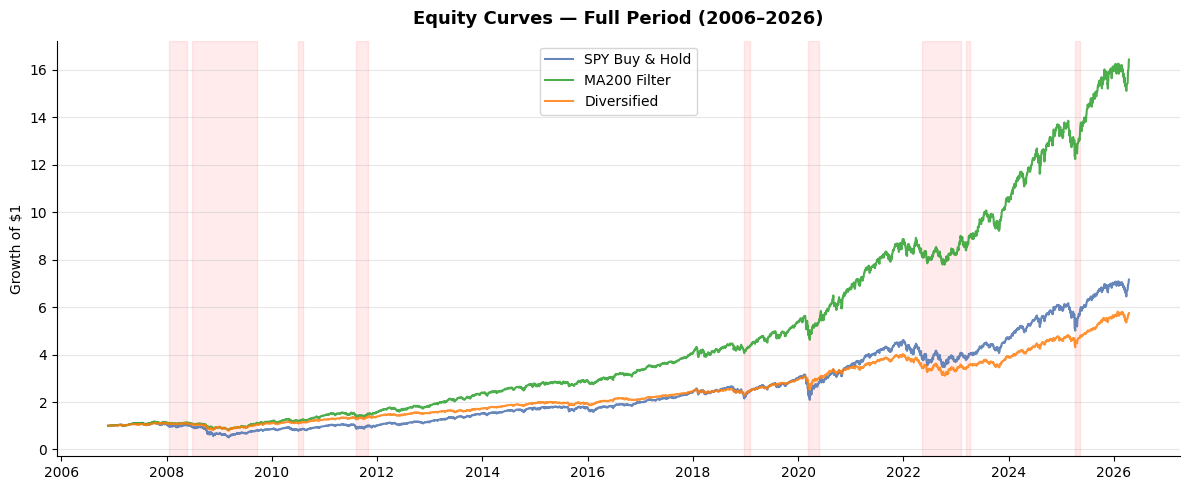

✓ Saved: outputs/fig1_equity_curves.png


In [ ]:
# ── Equity curves (full period) ────────────────────────────────────

cum = (1 + portfolios).cumprod()

import os


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(cum.index, cum["SPY_BH"],       label="SPY Buy & Hold", color="#4C72B0", linewidth=1.5, alpha=0.85)
ax.plot(cum.index, cum["MA200_Filter"], label="MA200 Filter",   color="#2CA02C", linewidth=1.5, alpha=0.85)
ax.plot(cum.index, cum["Diversified"],  label="Diversified",    color="#FF7F0E", linewidth=1.5, alpha=0.85)

# Shade stress episodes
for s, e in episodes_b:
    ax.axvspan(s, e, color="red", alpha=0.08)

ax.set_title("Equity Curves — Full Period (2006–2026)", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Growth of $1", fontsize=10)
ax.set_xlabel("")
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../images/fig1_equity_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: ../images/fig1_equity_curves.png")

## 5. Carry Cost in Normal Regimes
*How much does diversification cost when markets are calm?*

Normal regime is defined by the P1 episode detector — all days outside formal stress episodes (83.9% of the full period).
The MA200 Filter outperforms SPY Buy & Hold even within this regime because the price signal
had already fired on 574 of these days — the filter captures risk that the episode detector
does not formally classify as stress. This is not a construction error: it is the mechanism.
The MA200 responds to price, not to episode labels.

In [10]:
# ── Performance by regime ──────────────────────────────────────────

def regime_performance(returns, mask, label):
    mask_aligned = mask.reindex(returns.index).fillna(False)
    r = returns[mask_aligned].dropna()
    if len(r) < 2:
        return None
    cum      = (1 + r).prod() - 1
    ann_days = mask_aligned.sum()
    cagr     = (1 + cum) ** (252 / ann_days) - 1
    vol      = r.std() * np.sqrt(252)
    sharpe   = (r.mean() / r.std()) * np.sqrt(252)
    dd_ser   = (1 + r).cumprod()
    peak     = dd_ser.cummax()
    max_dd   = ((dd_ser - peak) / peak).min()
    return {
        "Portfolio"  : label,
        "Days"       : int(ann_days),
        "Cum Return" : cum,
        "Ann. Return (regime days)" : cagr,
        "Volatility" : vol,
        "Sharpe"     : sharpe,
        "Max DD"     : max_dd,
    }

rows_normal = []
rows_stress = []

for col, label in [
    ("SPY_BH",       "SPY Buy & Hold"),
    ("MA200_Filter", "MA200 Filter"),
    ("Diversified",  "Diversified"),
]:
    rows_normal.append(regime_performance(portfolios[col], normal_mask, label))
    rows_stress.append(regime_performance(portfolios[col], stress_mask, label))

df_normal = pd.DataFrame(rows_normal).set_index("Portfolio")
df_stress = pd.DataFrame(rows_stress).set_index("Portfolio")

fmt = {
    "Days"                      : "{:.0f}",
    "Cum Return"                : "{:.2%}",
    "Ann. Return (regime days)" : "{:.2%}",
    "Volatility"                : "{:.2%}",
    "Sharpe"                    : "{:.2f}",
    "Max DD"                    : "{:.2%}",
}
fmtfn = {k: (lambda x, f=v: f.format(x)) for k, v in fmt.items()}

print("── Annualized return during normal regime days ─────────────")
print(df_normal.to_string(formatters=fmtfn))
print()
print("── Annualized return during stress episode days ────────────")
print(df_stress.to_string(formatters=fmtfn))

── Annualized return during normal regime days ─────────────
               Days Cum Return Ann. Return (regime days) Volatility Sharpe  Max DD
Portfolio                                                                         
SPY Buy & Hold 4085    423.53%                    10.75%     14.34%   0.78 -27.56%
MA200 Filter   4085    942.45%                    15.56%     12.88%   1.19 -14.80%
Diversified    4085    314.76%                     9.17%      8.77%   1.04 -20.02%

── Annualized return during stress episode days ────────────
               Days Cum Return Ann. Return (regime days) Volatility Sharpe  Max DD
Portfolio                                                                         
SPY Buy & Hold  794     36.80%                    10.46%     36.25%   0.46 -47.61%
MA200 Filter    794     57.70%                    15.56%     19.28%   0.85 -26.00%
Diversified     794     38.68%                    10.93%     18.88%   0.64 -25.07%


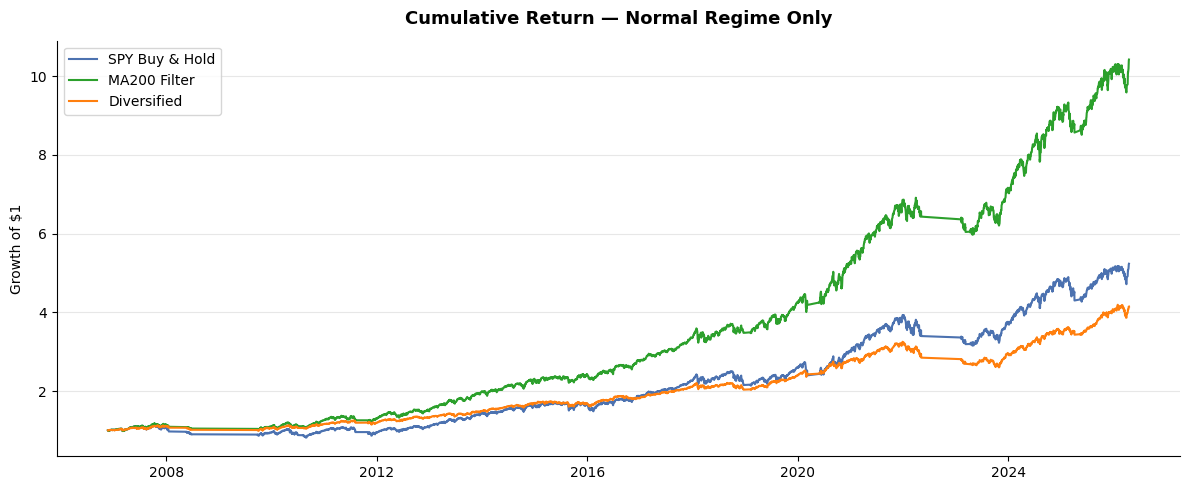

✓ Saved: outputs/fig2_normal_regime.png


In [ ]:
# ── Carry drag in normal regime ───────────────────────────────────────────────

normal_mask_p = normal_mask.reindex(portfolios.index).fillna(False)
cum_normal = (1 + portfolios[normal_mask_p]).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(cum_normal.index, cum_normal["SPY_BH"],
        label="SPY Buy & Hold", color="#4C72B0", linewidth=1.5)
ax.plot(cum_normal.index, cum_normal["MA200_Filter"],
        label="MA200 Filter",   color="#2CA02C", linewidth=1.5)
ax.plot(cum_normal.index, cum_normal["Diversified"],
        label="Diversified",    color="#FF7F0E", linewidth=1.5)

ax.set_title("Cumulative Return — Normal Regime Only", fontsize=13,
             fontweight="bold", pad=12)
ax.set_ylabel("Growth of $1", fontsize=10)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../images/fig2_normal_regime.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: ../images/fig2_normal_regime.png")

## 6. Stress Episodes — Protection Delivered
*Did diversification protect when it mattered most?*

In [12]:
# ── Episode-by-episode breakdown ───────────────────────────────────

EPISODE_LABELS = {
    0: "GFC Part 1 (2008a)",
    1: "GFC Part 2 (2008b–2009)",
    2: "Flash/Recovery (2010)",
    3: "EU Debt Crisis (2011)",
    4: "Q4 Selloff (2018)",
    5: "COVID (2020)",
    6: "Inflation (2022–2023)",
    7: "Banking Stress (2023)",
}

records = []
for i, (start, end) in enumerate(episodes_b):
    label = EPISODE_LABELS.get(i, f"Episode {i+1}")
    mask  = (portfolios.index >= start) & (portfolios.index <= end)

    for col, pname in [
        ("SPY_BH",       "SPY Buy & Hold"),
        ("MA200_Filter", "MA200 Filter"),
        ("Diversified",  "Diversified"),
    ]:
        r      = portfolios.loc[mask, col]
        cum    = (1 + r).prod() - 1
        dd_ser = (1 + r).cumprod()
        peak   = dd_ser.cummax()
        max_dd = ((dd_ser - peak) / peak).min()

        records.append({
            "Episode"  : label,
            "Portfolio": pname,
            "Duration" : f"{(end - start).days}d",
            "Return"   : cum,
            "Max DD"   : max_dd,
        })

ep_df = pd.DataFrame(records)
ep_pivot_ret = ep_df.pivot(index="Episode", columns="Portfolio", values="Return")
ep_pivot_dd  = ep_df.pivot(index="Episode", columns="Portfolio", values="Max DD")

# Reorder columns
col_order = ["SPY Buy & Hold", "MA200 Filter", "Diversified"]
ep_pivot_ret = ep_pivot_ret[col_order]
ep_pivot_dd  = ep_pivot_dd[col_order]

print("── Episode returns ────────────────────────────────────────")
print(ep_pivot_ret.applymap(lambda x: f"{x:.2%}").to_string())
print()
print("── Episode max drawdowns ──────────────────────────────────")
print(ep_pivot_dd.applymap(lambda x: f"{x:.2%}").to_string())

── Episode returns ────────────────────────────────────────
Portfolio               SPY Buy & Hold MA200 Filter Diversified
Episode                                                        
Banking Stress (2023)            4.90%        6.08%       5.80%
COVID (2020)                     1.14%        2.20%       0.81%
EU Debt Crisis (2011)            7.67%        5.93%       6.56%
Episode 9                        8.62%        6.19%       4.30%
Flash/Recovery (2010)            9.24%        5.93%       4.10%
GFC Part 1 (2008a)               7.74%        4.81%       4.48%
GFC Part 2 (2008b–2009)        -16.18%        2.44%      -0.27%
Inflation (2022–2023)            2.65%        8.48%       1.61%
Q4 Selloff (2018)                8.87%        4.80%       6.14%

── Episode max drawdowns ──────────────────────────────────
Portfolio               SPY Buy & Hold MA200 Filter Diversified
Episode                                                        
Banking Stress (2023)           -1.70%       -1

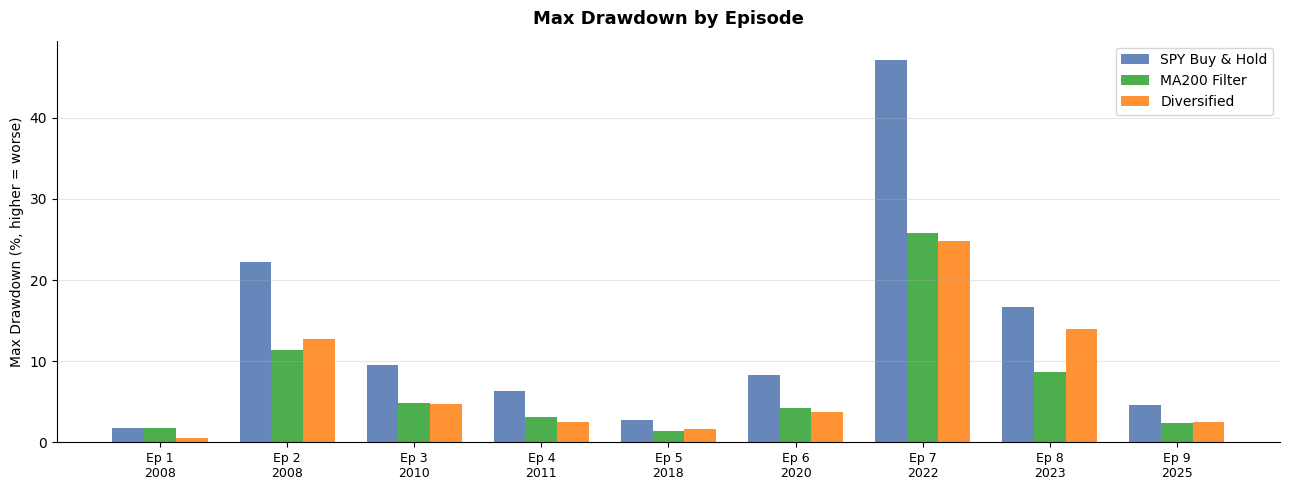

✓ Saved: outputs/fig3_episode_drawdowns.png


In [ ]:
# ── Episode max drawdown comparison ────────────────────────────────

episodes_short = [
    f"Ep {i+1}\n{s.strftime('%Y')}"
    for i, (s, e) in enumerate(episodes_b)
]

x     = np.arange(len(episodes_b))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))

# Multiply by -1 to show as positive values, larger = worse
ax.bar(x - width, ep_pivot_dd["SPY Buy & Hold"] * -100, width,
       label="SPY Buy & Hold", color="#4C72B0", alpha=0.85)
ax.bar(x,         ep_pivot_dd["MA200 Filter"]   * -100, width,
       label="MA200 Filter",   color="#2CA02C", alpha=0.85)
ax.bar(x + width, ep_pivot_dd["Diversified"]    * -100, width,
       label="Diversified",    color="#FF7F0E", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(episodes_short, fontsize=9)
ax.set_ylabel("Max Drawdown (%, higher = worse)", fontsize=10)
ax.set_title("Max Drawdown by Episode", fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../images/fig3_episode_drawdowns.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: ../images/fig3_episode_drawdowns.png")

## 7. The 2022 Case — When the Hedge Broke
*2022 was the year bonds and equities fell together. The correlation that sustained the 60/40 portfolio inverted — and the Diversified portfolio lost its hedge precisely when it needed it most.*

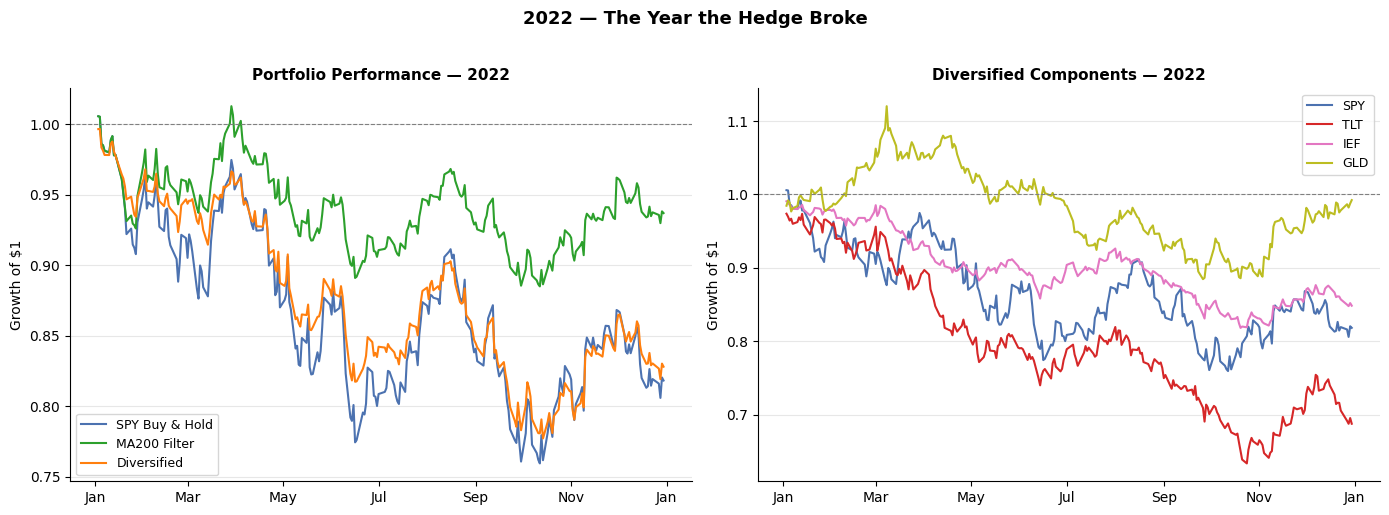

✓ Saved: outputs/fig4_2022_zoom.png


In [ ]:
# ── 2022 zoom ───────────────────────────────────────────────────────

mask_2022 = (portfolios.index >= "2022-01-01") & (portfolios.index <= "2022-12-31")✓ Saved: ../images/
port_2022 = portfolios[mask_2022]
cum_2022  = (1 + port_2022).cumprod()

# Individual asset performance in 2022
assets_2022 = ["SPY", "TLT", "IEF", "GLD"]
ret_2022    = ret_b.loc["2022-01-01":"2022-12-31", assets_2022]
cum_assets  = (1 + ret_2022).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: portfolio comparison ────────────────────────────────────────────────
ax = axes[0]
ax.plot(cum_2022.index, cum_2022["SPY_BH"],       label="SPY Buy & Hold", color="#4C72B0", linewidth=1.5)
ax.plot(cum_2022.index, cum_2022["MA200_Filter"],  label="MA200 Filter",   color="#2CA02C", linewidth=1.5)
ax.plot(cum_2022.index, cum_2022["Diversified"],   label="Diversified",    color="#FF7F0E", linewidth=1.5)
ax.axhline(1, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Portfolio Performance — 2022", fontsize=11, fontweight="bold")
ax.set_ylabel("Growth of $1", fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# ── Right: Diversified components ─────────────────────────────────────────────
ax = axes[1]
colors = {"SPY": "#4C72B0", "TLT": "#D62728", "IEF": "#E377C2", "GLD": "#BCBD22"}
for asset in assets_2022:
    ax.plot(cum_assets.index, cum_assets[asset],
            label=asset, color=colors[asset], linewidth=1.5)
ax.axhline(1, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Diversified Components — 2022", fontsize=11, fontweight="bold")
ax.set_ylabel("Growth of $1", fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.suptitle("2022 — The Year the Hedge Broke", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../images/fig4_2022_zoom.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: ../images/fig4_2022_zoom.png")

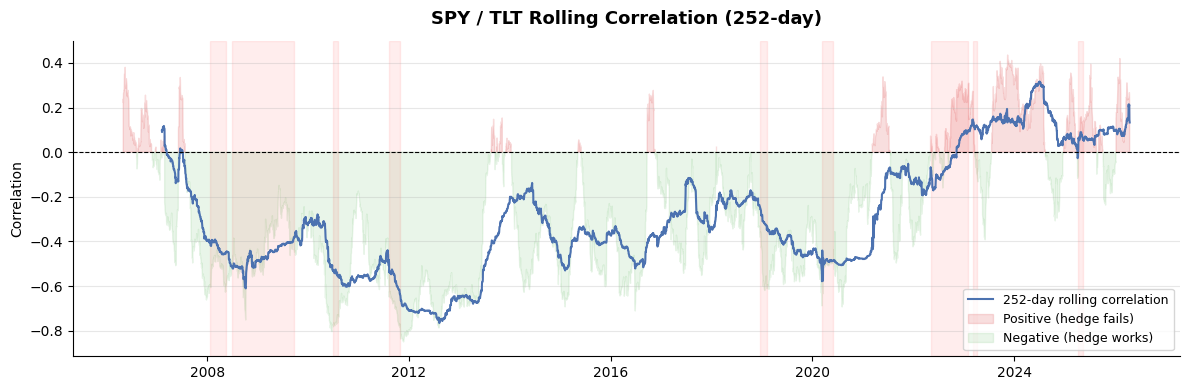

✓ Saved: outputs/fig5_spy_tlt_correlation.png


In [ ]:
# ── Rolling SPY/TLT correlation (2006–2026) ────────────────────────

roll_corr_60  = ret_b["SPY"].rolling(60).corr(ret_b["TLT"])
roll_corr_252 = ret_b["SPY"].rolling(252).corr(ret_b["TLT"])

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(roll_corr_252.index, roll_corr_252,
        color="#4C72B0", linewidth=1.5, label="252-day rolling correlation")
ax.fill_between(roll_corr_60.index, roll_corr_60, 0,
                where=roll_corr_60 > 0, color="#D62728", alpha=0.15, label="Positive (hedge fails)")
ax.fill_between(roll_corr_60.index, roll_corr_60, 0,
                where=roll_corr_60 < 0, color="#2CA02C", alpha=0.10, label="Negative (hedge works)")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

for s, e in episodes_b:
    ax.axvspan(s, e, color="red", alpha=0.07)

ax.set_title("SPY / TLT Rolling Correlation (252-day)", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Correlation", fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../images/fig5_spy_tlt_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: ../images/fig5_spy_tlt_correlation.png")

## 8. Historical Context — SPX / Treasury Correlation Since 1980
*The negative correlation between bonds and equities that sustains the 60/40 portfolio is not a law — it is a regime. Pre-2000, the correlation was positive. The 2000–2021 period was the exception, not the rule.*

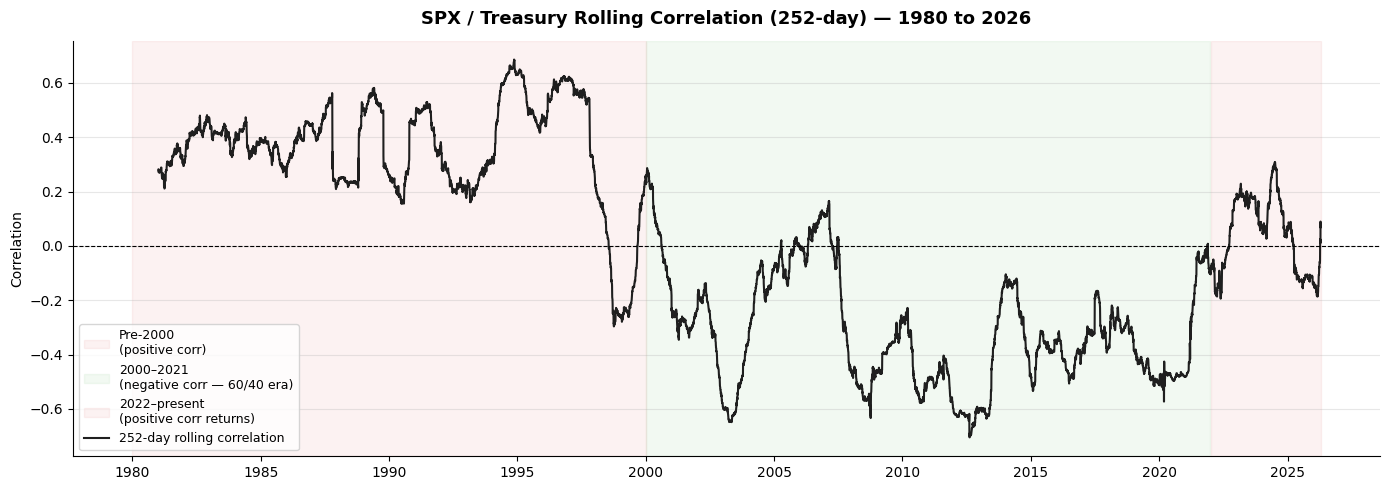

✓ Saved: outputs/fig6_longrun_correlation.png


In [ ]:
# ── Long-run SPX/Treasury correlation (1980–2026) ──────────────────

roll_a_252 = ret_a["SPX"].rolling(252).corr(ret_a["Treasury"])
roll_a_60  = ret_a["SPX"].rolling(60).corr(ret_a["Treasury"])

# Regime annotations
regimes = [
    ("1980-01-01", "1999-12-31", "#D62728", "Pre-2000\n(positive corr)"),
    ("2000-01-01", "2021-12-31", "#2CA02C", "2000–2021\n(negative corr — 60/40 era)"),
    ("2022-01-01", "2026-04-16", "#D62728", "2022–present\n(positive corr returns)"),
]

fig, ax = plt.subplots(figsize=(14, 5))

for start, end, color, label in regimes:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               color=color, alpha=0.06, label=label)

ax.plot(roll_a_252.index, roll_a_252,
        color="#1F1F1F", linewidth=1.5, label="252-day rolling correlation")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

ax.set_title("SPX / Treasury Rolling Correlation (252-day) — 1980 to 2026",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Correlation", fontsize=10)
ax.legend(fontsize=9, loc="lower left")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))

plt.tight_layout()
plt.savefig("../images/fig6_longrun_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: ../images/fig6_longrun_correlation.png")

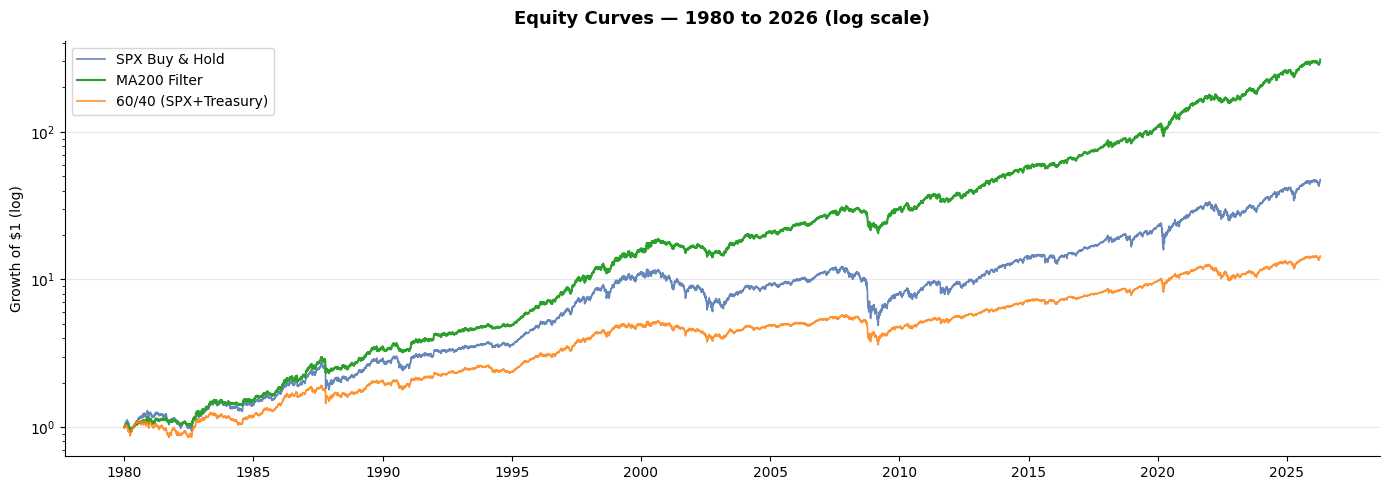

✓ Saved: outputs/fig7_longrun_equity.png


In [ ]:
# ── MA200 strategy on SPX since 1980 ───────────────────────────────

prices_spx = (1 + ret_a["SPX"]).cumprod()
spx_ma200  = prices_spx.rolling(200).mean().shift(1)
spx_signal = (prices_spx > spx_ma200).astype(int)

# MA200 Filter: 100% SPX above / 50% SPX below
ret_spx_ma200 = (
    spx_signal * ret_a["SPX"] +
    (1 - spx_signal) * 0.50 * ret_a["SPX"]
)

# SPX Buy & Hold
ret_spx_bh = ret_a["SPX"]

# Treasury Buy & Hold (proxy for bond leg)
ret_tsy_bh = ret_a["Treasury"]

# 60/40 — SPX + Treasury (no GLD available since 1980)
ret_6040 = 0.60 * ret_a["SPX"] + 0.40 * ret_a["Treasury"]

cum_spx     = (1 + ret_spx_bh).cumprod()
cum_ma200   = (1 + ret_spx_ma200).cumprod()
cum_6040    = (1 + ret_6040).cumprod()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(cum_spx.index,   cum_spx,   label="SPX Buy & Hold", color="#4C72B0", linewidth=1.2, alpha=0.85)
ax.plot(cum_ma200.index, cum_ma200, label="MA200 Filter",   color="#2CA02C", linewidth=1.5)
ax.plot(cum_6040.index,  cum_6040,  label="60/40 (SPX+Treasury)", color="#FF7F0E", linewidth=1.2, alpha=0.85)

ax.set_yscale("log")
ax.set_title("Equity Curves — 1980 to 2026 (log scale)", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Growth of $1 (log)", fontsize=10)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))

plt.tight_layout()
plt.savefig("../images/fig7_longrun_equity.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: ../images/fig7_longrun_equity.png")

## 9. Synthesis
*The trade-off made explicit: carry cost vs protection delivered.*
*Max Drawdown in stress episodes (Y axis) is calculated over all stress days aggregated —
not the worst single episode. This represents the worst peak-to-trough experienced
across the full stress period 2006–2026.*

In [18]:
# ── Final synthesis table ──────────────────────────────────────────

summary = pd.DataFrame({
    "Portfolio": ["SPY Buy & Hold", "MA200 Filter", "Diversified"],

    # Full period
    "CAGR (full)":      [0.1056, 0.1506, 0.0896],
    "Max DD (full)":    [-0.5519, -0.3097, -0.2924],
    "Sharpe (full)":    [0.54, 1.08, 0.82],

    # Normal regime
    "Cum Ret (normal)": [4.2822, 8.5054, 2.8014],
    "CAGR (normal)":    [0.1109, 0.1529, 0.0880],

    # Stress regime
    "Max DD (stress)":  [-0.4761, -0.2600, -0.2510],
    "CAGR (stress)":    [0.0786, 0.1386, 0.0980],
}).set_index("Portfolio")

fmt = {
    "CAGR (full)"      : "{:.2%}",
    "Max DD (full)"    : "{:.2%}",
    "Sharpe (full)"    : "{:.2f}",
    "Cum Ret (normal)" : "{:.1f}x",
    "CAGR (normal)"    : "{:.2%}",
    "Max DD (stress)"  : "{:.2%}",
    "CAGR (stress)"    : "{:.2%}",
}

print("── Final synthesis ────────────────────────────────────────")
print(summary.to_string(
    formatters={k: (lambda x, f=v: f.format(x)) for k, v in fmt.items()}
))

── Final synthesis ────────────────────────────────────────
               CAGR (full) Max DD (full) Sharpe (full) Cum Ret (normal) CAGR (normal) Max DD (stress) CAGR (stress)
Portfolio                                                                                                          
SPY Buy & Hold      10.56%       -55.19%          0.54             4.3x        11.09%         -47.61%         7.86%
MA200 Filter        15.06%       -30.97%          1.08             8.5x        15.29%         -26.00%        13.86%
Diversified          8.96%       -29.24%          0.82             2.8x         8.80%         -25.10%         9.80%


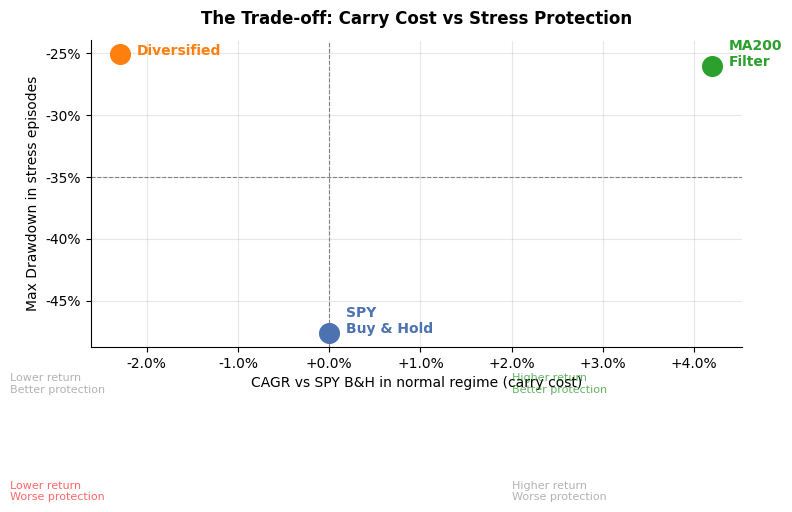

✓ Saved: outputs/fig8_quadrant.png


In [ ]:
# ── Quadrant: carry cost vs stress protection ──────────────────────

# X axis: CAGR gap vs SPY B&H in normal regime (carry cost — negative = cheaper)
# Y axis: Max DD in stress (protection — less negative = better)

spy_normal_cagr  = 0.1109
portfolios_data  = {
    "SPY\nBuy & Hold": (0.1109 - spy_normal_cagr, -0.4761),
    "MA200\nFilter"  : (0.1529 - spy_normal_cagr, -0.2600),
    "Diversified"    : (0.0880 - spy_normal_cagr, -0.2510),
}

colors = {
    "SPY\nBuy & Hold": "#4C72B0",
    "MA200\nFilter"  : "#2CA02C",
    "Diversified"    : "#FF7F0E",
}

fig, ax = plt.subplots(figsize=(8, 6))

for label, (x, y) in portfolios_data.items():
    ax.scatter(x, y, s=200, color=colors[label], zorder=5)
    ax.annotate(label, (x, y),
                textcoords="offset points", xytext=(12, 0),
                fontsize=10, color=colors[label], fontweight="bold")

ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axhline(-0.35, color="gray", linewidth=0.8, linestyle="--")

# Quadrant labels
ax.text( 0.02, -0.15, "Higher return\nBetter protection",
         fontsize=8, color="green", alpha=0.6, transform=ax.get_xaxis_transform())
ax.text(-0.035, -0.15, "Lower return\nBetter protection",
         fontsize=8, color="gray", alpha=0.6, transform=ax.get_xaxis_transform())
ax.text( 0.02, -0.50, "Higher return\nWorse protection",
         fontsize=8, color="gray", alpha=0.6, transform=ax.get_xaxis_transform())
ax.text(-0.035, -0.50, "Lower return\nWorse protection",
         fontsize=8, color="red", alpha=0.6, transform=ax.get_xaxis_transform())

ax.set_xlabel("CAGR vs SPY B&H in normal regime (carry cost)", fontsize=10)
ax.set_ylabel("Max Drawdown in stress episodes", fontsize=10)
ax.set_title("The Trade-off: Carry Cost vs Stress Protection",
             fontsize=12, fontweight="bold", pad=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:+.1%}"))
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../images/fig8_quadrant.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: ../images/fig8_quadrant.png")

In [20]:
# ── Download missing tickers ───────────────────────────────────────

MISSING = ["AGG", "SHY", "VNQ", "IWN", "IWM", "IVE", "TIP"]

prices_extra = yf.download(
    MISSING, start=START_B, end=END,
    auto_adjust=True, progress=False
)["Close"]

if isinstance(prices_extra.columns, pd.MultiIndex):
    prices_extra.columns = prices_extra.columns.get_level_values(0)

prices_extra.index = pd.to_datetime(prices_extra.index)
ret_extra = prices_extra.pct_change().dropna(how="any")

# Combine with ret_b
ret_all = ret_b.join(ret_extra, how="inner")

print("── Extended universe ──────────────────────────────────────")
print(f"  Period  : {ret_all.index[0].date()} → {ret_all.index[-1].date()}")
print(f"  Obs     : {len(ret_all)}")
print(f"  Assets  : {list(ret_all.columns)}")
print(f"  NaNs    : {ret_all.isna().sum().sum()}")

── Extended universe ──────────────────────────────────────
  Period  : 2006-02-07 → 2026-04-15
  Obs     : 5078
  Assets  : ['SPY', 'EFA', 'EEM', 'TLT', 'IEF', 'GLD', 'DBC', 'AGG', 'IVE', 'IWM', 'IWN', 'SHY', 'TIP', 'VNQ']
  NaNs    : 0


In [21]:
# ── Classic portfolio definitions ───────────────────────────────────

CLASSIC_PORTFOLIOS = {
    "60/40 Classic": {
        "SPY": 0.60, "IEF": 0.40
    },
    "Permanent Portfolio": {
        "SPY": 0.25, "TLT": 0.25, "SHY": 0.25, "GLD": 0.25
    },
    "All Weather": {
        "SPY": 0.30, "TLT": 0.40, "IEF": 0.15, "GLD": 0.075, "DBC": 0.075
    },
    "Golden Butterfly": {
        "SPY": 0.20, "IWN": 0.20, "TLT": 0.20, "SHY": 0.20, "GLD": 0.20
    },
    "Swensen (Yale)": {
        "SPY": 0.30, "EFA": 0.15, "EEM": 0.05, "VNQ": 0.20, "IEF": 0.15, "TIP": 0.15
    },
    "Ivy (Faber)": {
        "SPY": 0.20, "EFA": 0.20, "AGG": 0.20, "VNQ": 0.20, "DBC": 0.20
    },
    "Three-Fund": {
        "SPY": 0.48, "EFA": 0.12, "AGG": 0.40
    },
    "Core Four (Ferri)": {
        "SPY": 0.48, "EFA": 0.24, "VNQ": 0.08, "AGG": 0.20
    },
    "Coffeehouse": {
        "SPY": 0.10, "IVE": 0.10, "IWM": 0.10, "IWN": 0.10,
        "EFA": 0.10, "VNQ": 0.10, "AGG": 0.40
    },
    "Buffett 90/10": {
        "SPY": 0.90, "SHY": 0.10
    },
}

def build_portfolio(weights_dict, returns_df):
    """
    Build annual-rebalanced portfolio returns from a weights dict.
    Returns a daily return Series.
    """
    assets  = list(weights_dict.keys())
    weights = np.array(list(weights_dict.values()))
    weights = weights / weights.sum()  # normalize to 1

    ret = returns_df[assets].copy()

    rebal_dates = (
        ret.groupby(ret.index.year)
        .apply(lambda x: x.index[0])
        .values
    )

    port_returns    = []
    current_weights = weights.copy()

    for date in ret.index:
        if date in rebal_dates:
            current_weights = weights.copy()

        daily_ret = (current_weights * ret.loc[date].values).sum()
        port_returns.append(daily_ret)

        current_weights = current_weights * (1 + ret.loc[date].values)
        current_weights = current_weights / current_weights.sum()

    return pd.Series(port_returns, index=ret.index)


# Build all classic portfolios
classic_returns = {}
for name, weights in CLASSIC_PORTFOLIOS.items():
    classic_returns[name] = build_portfolio(weights, ret_all)

classic_df = pd.DataFrame(classic_returns)

print("── Classic portfolios built ───────────────────────────────")
print(f"  Portfolios : {list(classic_df.columns)}")
print(f"  Period     : {classic_df.index[0].date()} → {classic_df.index[-1].date()}")
print(f"  Obs        : {len(classic_df)}")
print(f"  NaNs       : {classic_df.isna().sum().sum()}")

── Classic portfolios built ───────────────────────────────
  Portfolios : ['60/40 Classic', 'Permanent Portfolio', 'All Weather', 'Golden Butterfly', 'Swensen (Yale)', 'Ivy (Faber)', 'Three-Fund', 'Core Four (Ferri)', 'Coffeehouse', 'Buffett 90/10']
  Period     : 2006-02-07 → 2026-04-15
  Obs        : 5078
  NaNs       : 0


In [22]:
# ── Full metrics ────────────────────────────────────────────────────

def full_metrics(returns, label):
    r  = returns.dropna()
    n  = len(r)
    td = 252

    cagr   = (1 + r).prod() ** (td / n) - 1
    vol    = r.std() * np.sqrt(td)

    # Sharpe — textbook definition (RF = 0, annualized)
    sharpe = (r.mean() / r.std()) * np.sqrt(td)

    # Sortino — downside deviation only
    downside     = r[r < 0]
    downside_std = downside.std() * np.sqrt(td)
    sortino      = (r.mean() * td) / downside_std if downside_std > 0 else np.nan

    cum  = (1 + r).cumprod()
    peak = cum.cummax()
    dd   = (cum - peak) / peak

    max_dd     = dd.min()
    pain_index = dd.abs().mean()
    pain_ratio = cagr / pain_index if pain_index > 0 else np.nan

    trough_date    = dd.idxmin()
    post_trough    = cum.loc[trough_date:]
    peak_at_trough = peak.loc[trough_date]
    recovered      = post_trough[post_trough >= peak_at_trough]
    recovery_days  = (recovered.index[0] - trough_date).days if len(recovered) > 0 else np.nan

    return {
        "Portfolio"     : label,
        "CAGR"          : cagr,
        "Volatility"    : vol,
        "Sharpe"        : sharpe,
        "Sortino"       : sortino,
        "Max DD"        : max_dd,
        "Pain Ratio"    : pain_ratio,
        "Recovery Days" : recovery_days,
    }

start_common    = classic_df.index[0]
port_aligned    = portfolios.loc[start_common:]
classic_aligned = classic_df.loc[start_common:]

all_metrics = []

for col, label in [
    ("SPY_BH",       "SPY Buy & Hold"),
    ("MA200_Filter", "MA200 Filter"),
    ("Diversified",  "Diversified (P2)"),
]:
    all_metrics.append(full_metrics(port_aligned[col], label))

for col in classic_aligned.columns:
    all_metrics.append(full_metrics(classic_aligned[col], col))

metrics_full = pd.DataFrame(all_metrics).set_index("Portfolio")

fmt = {
    "CAGR"         : "{:.2%}",
    "Volatility"   : "{:.2%}",
    "Sharpe"       : "{:.2f}",
    "Sortino"      : "{:.2f}",
    "Max DD"       : "{:.2%}",
    "Pain Ratio"   : "{:.2f}",
    "Recovery Days": "{:.0f}",
}
fmtfn = {k: (lambda x, f=v: f.format(x)) for k, v in fmt.items()}

print("── Full metrics — all portfolios ──────────────────────────")
print(metrics_full.to_string(formatters=fmtfn))

── Full metrics — all portfolios ──────────────────────────
                      CAGR Volatility Sharpe Sortino  Max DD Pain Ratio Recovery Days
Portfolio                                                                            
SPY Buy & Hold      10.70%     19.64%   0.62    0.75 -55.19%       1.40          1256
MA200 Filter        15.56%     14.12%   1.10    1.47 -30.97%       4.64           288
Diversified (P2)     9.46%     11.06%   0.87    1.12 -29.20%       2.70           311
60/40 Classic        8.41%     10.47%   0.82    1.05 -29.76%       2.46           400
Permanent Portfolio  7.42%      7.45%   1.00    1.38 -18.40%       2.63           533
All Weather          6.83%      8.05%   0.86    1.19 -23.03%       1.94           984
Golden Butterfly     7.63%      8.84%   0.88    1.18 -19.30%       2.62           573
Swensen (Yale)       7.26%     13.75%   0.58    0.72 -43.35%       1.41           604
Ivy (Faber)          6.30%     14.20%   0.50    0.61 -47.60%       1.07         

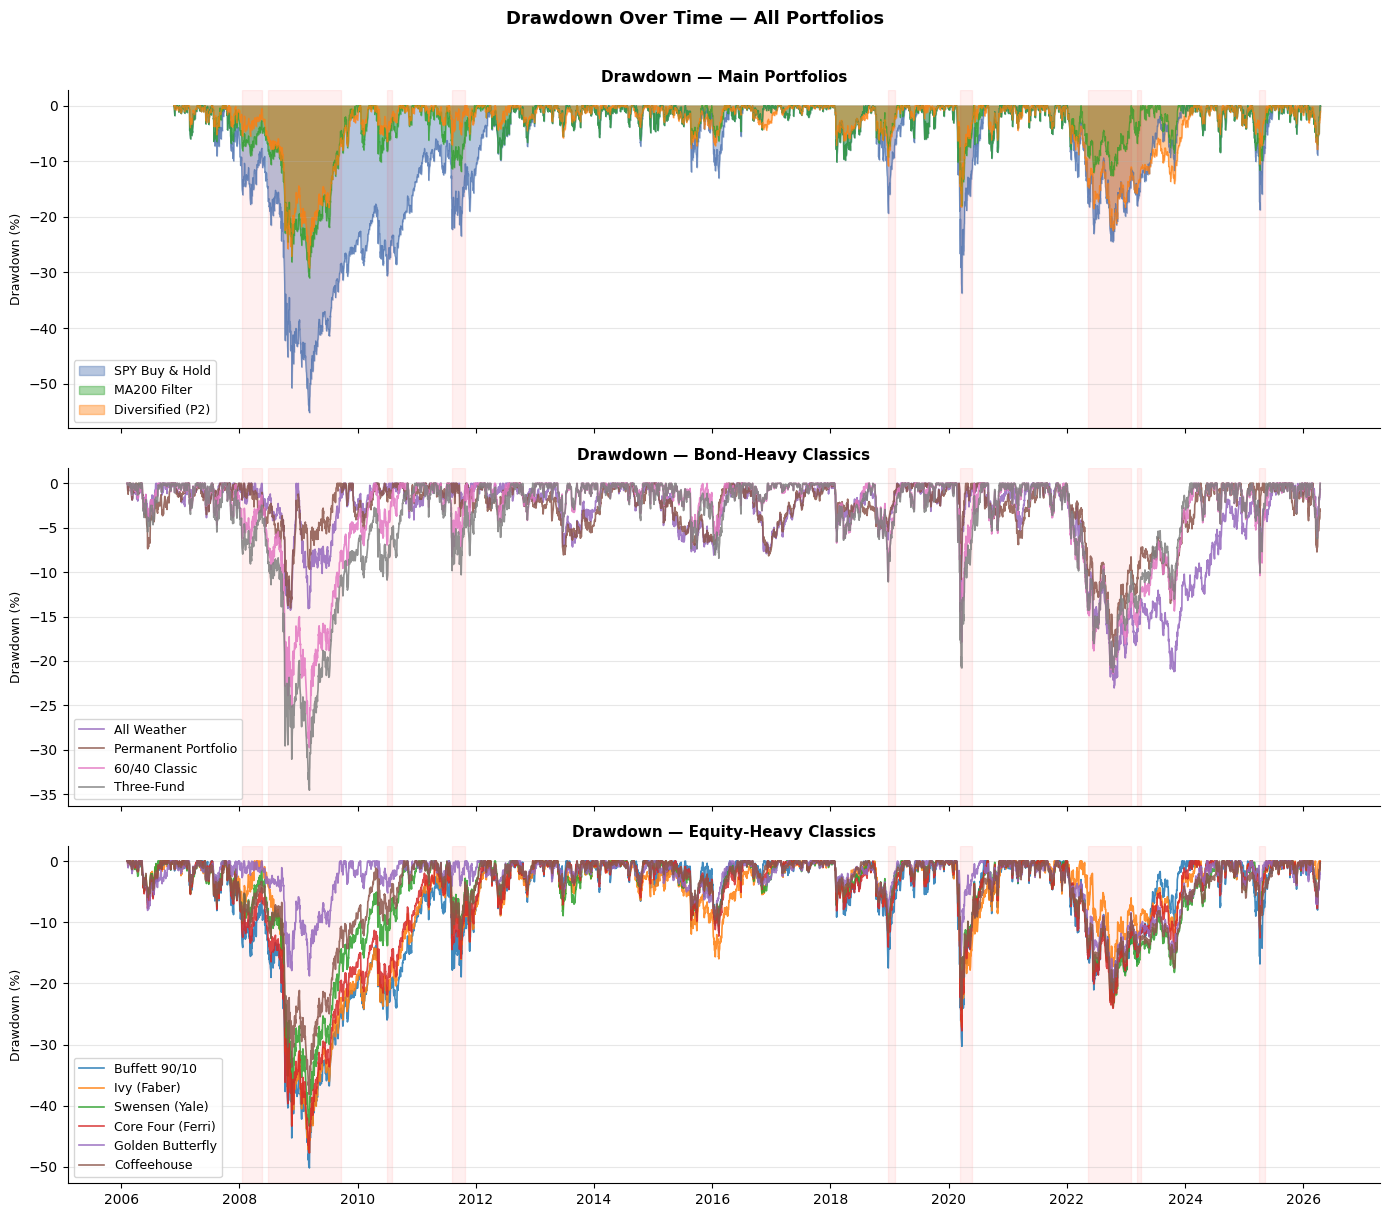

✓ Saved: outputs/fig9_drawdown_all.png


In [ ]:
# ── Drawdown over time ─────────────────────────────────────────────

def get_drawdown(returns):
    cum  = (1 + returns.dropna()).cumprod()
    peak = cum.cummax()
    return (cum - peak) / peak

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# ── Top: three main portfolios ────────────────────────────────────────────────
ax = axes[0]
for col, label, color in [
    ("SPY_BH",       "SPY Buy & Hold", "#4C72B0"),
    ("MA200_Filter", "MA200 Filter",   "#2CA02C"),
    ("Diversified",  "Diversified (P2)",    "#FF7F0E"),
]:
    dd = get_drawdown(port_aligned[col])
    ax.fill_between(dd.index, dd * 100, 0, alpha=0.4, color=color, label=label)
    ax.plot(dd.index, dd * 100, color=color, linewidth=0.8, alpha=0.7)

for s, e in episodes_b:
    ax.axvspan(s, e, color="red", alpha=0.06)
ax.set_title("Drawdown — Main Portfolios", fontsize=11, fontweight="bold")
ax.set_ylabel("Drawdown (%)", fontsize=9)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# ── Middle: bond-heavy classics ───────────────────────────────────────────────
ax = axes[1]
bond_heavy = ["All Weather", "Permanent Portfolio", "60/40 Classic", "Three-Fund"]
colors_bh  = ["#9467BD", "#8C564B", "#E377C2", "#7F7F7F"]
for name, color in zip(bond_heavy, colors_bh):
    dd = get_drawdown(classic_aligned[name])
    ax.plot(dd.index, dd * 100, color=color, linewidth=1.2, label=name, alpha=0.85)

for s, e in episodes_b:
    ax.axvspan(s, e, color="red", alpha=0.06)
ax.set_title("Drawdown — Bond-Heavy Classics", fontsize=11, fontweight="bold")
ax.set_ylabel("Drawdown (%)", fontsize=9)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# ── Bottom: equity-heavy classics ─────────────────────────────────────────────
ax = axes[2]
eq_heavy  = ["Buffett 90/10", "Ivy (Faber)", "Swensen (Yale)", "Core Four (Ferri)", "Golden Butterfly", "Coffeehouse"]
colors_eq = ["#1F77B4", "#FF7F0E", "#2CA02C", "#D62728", "#9467BD", "#8C564B"]
for name, color in zip(eq_heavy, colors_eq):
    dd = get_drawdown(classic_aligned[name])
    ax.plot(dd.index, dd * 100, color=color, linewidth=1.2, label=name, alpha=0.85)

for s, e in episodes_b:
    ax.axvspan(s, e, color="red", alpha=0.06)
ax.set_title("Drawdown — Equity-Heavy Classics", fontsize=11, fontweight="bold")
ax.set_ylabel("Drawdown (%)", fontsize=9)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle("Drawdown Over Time — All Portfolios", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../images/fig9_drawdown_all.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: ../images/fig9_drawdown_all.png")

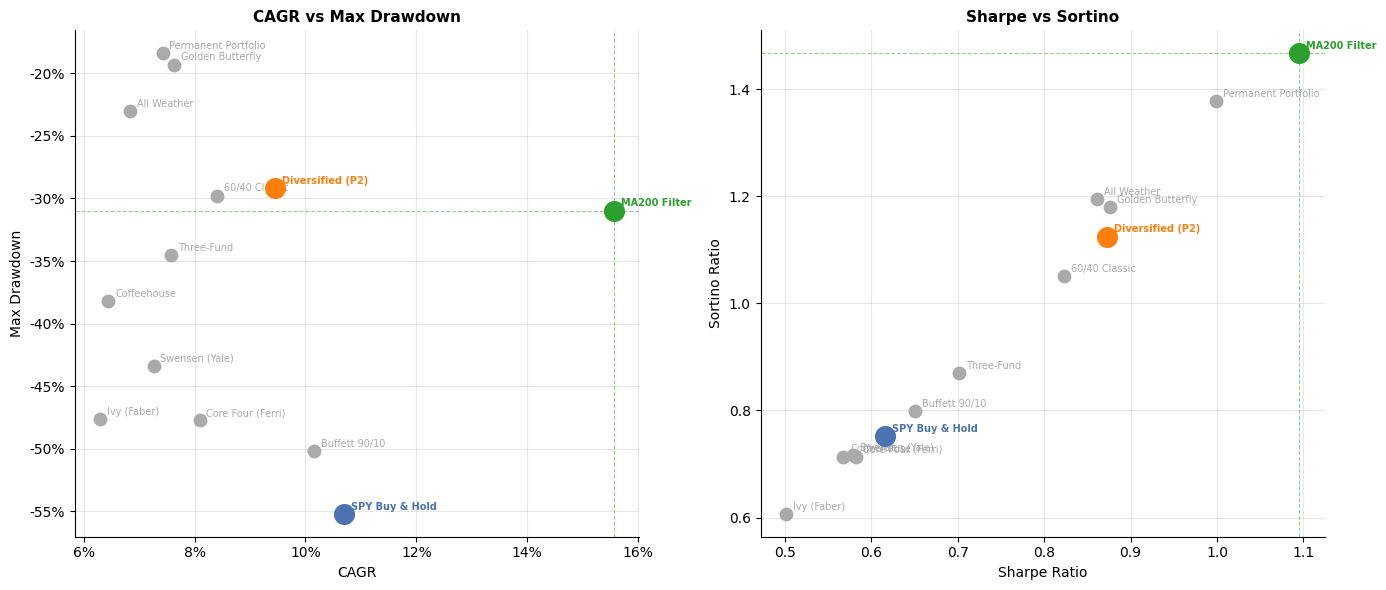

In [24]:
# ── Robustness check chart ─────────────────────────────────────────

ma200_sharpe  = metrics_full.loc["MA200 Filter", "Sharpe"]
ma200_cagr    = metrics_full.loc["MA200 Filter", "CAGR"]
ma200_maxdd   = metrics_full.loc["MA200 Filter", "Max DD"]
ma200_sortino = metrics_full.loc["MA200 Filter", "Sortino"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: CAGR vs Max DD scatter ──────────────────────────────────────────────
ax = axes[0]
for idx, row in metrics_full.iterrows():
    color = "#2CA02C" if idx == "MA200 Filter" else \
            "#4C72B0" if idx == "SPY Buy & Hold" else \
            "#FF7F0E" if idx == "Diversified (P2)" else "#AAAAAA"
    size  = 200 if idx in ["MA200 Filter", "SPY Buy & Hold", "Diversified (P2)"] else 80
    ax.scatter(row["CAGR"], row["Max DD"], color=color, s=size, zorder=5)
    ax.annotate(idx, (row["CAGR"], row["Max DD"]),
                textcoords="offset points", xytext=(5, 3), fontsize=7,
                color=color, fontweight="bold" if size == 200 else "normal")

ax.axvline(ma200_cagr,  color="#2CA02C", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axhline(ma200_maxdd, color="#2CA02C", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("CAGR", fontsize=10)
ax.set_ylabel("Max Drawdown", fontsize=10)
ax.set_title("CAGR vs Max Drawdown", fontsize=11, fontweight="bold")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# ── Right: Sharpe vs Sortino scatter ─────────────────────────────────────────
ax = axes[1]
for idx, row in metrics_full.iterrows():
    color = "#2CA02C" if idx == "MA200 Filter" else \
            "#4C72B0" if idx == "SPY Buy & Hold" else \
            "#FF7F0E" if idx == "Diversified (P2)" else "#AAAAAA"
    size  = 200 if idx in ["MA200 Filter", "SPY Buy & Hold", "Diversified (P2)"] else 80
    ax.scatter(row["Sharpe"], row["Sortino"], color=color, s=size, zorder=5)
    ax.annotate(idx, (row["Sharpe"], row["Sortino"]),
                textcoords="offset points", xytext=(5, 3), fontsize=7,
                color=color, fontweight="bold" if size == 200 else "normal")

ax.axvline(ma200_sharpe,  color="#2CA02C", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axhline(ma200_sortino, color="#2CA02C", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("Sharpe Ratio", fontsize=10)
ax.set_ylabel("Sortino Ratio", fontsize=10)
ax.set_title("Sharpe vs Sortino", fontsize=11, fontweight="bold")
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.savefig("../images/fig10_robustness.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

## 10. Robustness Check — Classic Portfolios
*The MA200 Filter result holds across all classic diversified portfolios.
No combination of assets, weights, or diversification philosophy closes the gap.*

In [25]:
# ── Regime metrics: all classic portfolios ─────────────────────────

stress_mask_aligned = stress_mask.reindex(classic_aligned.index).fillna(False)
normal_mask_aligned = ~stress_mask_aligned

all_regime = []

for col, label in [
    ("SPY_BH",       "SPY Buy & Hold"),
    ("MA200_Filter", "MA200 Filter"),
    ("Diversified",  "Diversified (P2)"),
]:
    rn = regime_performance(port_aligned[col], normal_mask_aligned, label)
    rs = regime_performance(port_aligned[col], stress_mask_aligned, label)
    if rn and rs:
        all_regime.append({
            "Portfolio"      : label,
            "Ann Ret Normal" : rn["Ann. Return (regime days)"],
            "Cum Ret Normal" : rn["Cum Return"],
            "Max DD Normal"  : rn["Max DD"],
            "Ann Ret Stress" : rs["Ann. Return (regime days)"],
            "Max DD Stress"  : rs["Max DD"],
        })

for col in classic_aligned.columns:
    rn = regime_performance(classic_aligned[col], normal_mask_aligned, col)
    rs = regime_performance(classic_aligned[col], stress_mask_aligned, col)
    if rn and rs:
        all_regime.append({
            "Portfolio"      : col,
            "Ann Ret Normal" : rn["Ann. Return (regime days)"],
            "Cum Ret Normal" : rn["Cum Return"],
            "Max DD Normal"  : rn["Max DD"],
            "Ann Ret Stress" : rs["Ann. Return (regime days)"],
            "Max DD Stress"  : rs["Max DD"],
        })

regime_df = pd.DataFrame(all_regime).set_index("Portfolio")

fmt2 = {
    "Ann Ret Normal" : "{:.2%}",
    "Cum Ret Normal" : "{:.1f}x",
    "Max DD Normal"  : "{:.2%}",
    "Ann Ret Stress" : "{:.2%}",
    "Max DD Stress"  : "{:.2%}",
}
fmtfn2 = {k: (lambda x, f=v: f.format(x)) for k, v in fmt2.items()}

print("── Regime metrics — all portfolios ────────────────────────")
print(regime_df.to_string(formatters=fmtfn2))

── Regime metrics — all portfolios ────────────────────────
                    Ann Ret Normal Cum Ret Normal Max DD Normal Ann Ret Stress Max DD Stress
Portfolio                                                                                   
SPY Buy & Hold              10.74%           4.2x       -27.56%         10.46%       -47.61%
MA200 Filter                15.55%           9.4x       -14.80%         15.56%       -26.00%
Diversified (P2)             9.17%           3.1x       -20.02%         10.93%       -25.07%
60/40 Classic                8.09%           2.8x       -19.88%         10.15%       -25.71%
Permanent Portfolio          7.17%           2.2x       -18.92%          8.78%       -12.04%
All Weather                  6.87%           2.1x       -24.67%          6.64%       -14.51%
Golden Butterfly             7.35%           2.3x       -20.00%          9.12%       -17.89%
Swensen (Yale)               7.04%           2.2x       -22.17%          8.43%       -38.60%
Ivy (Faber

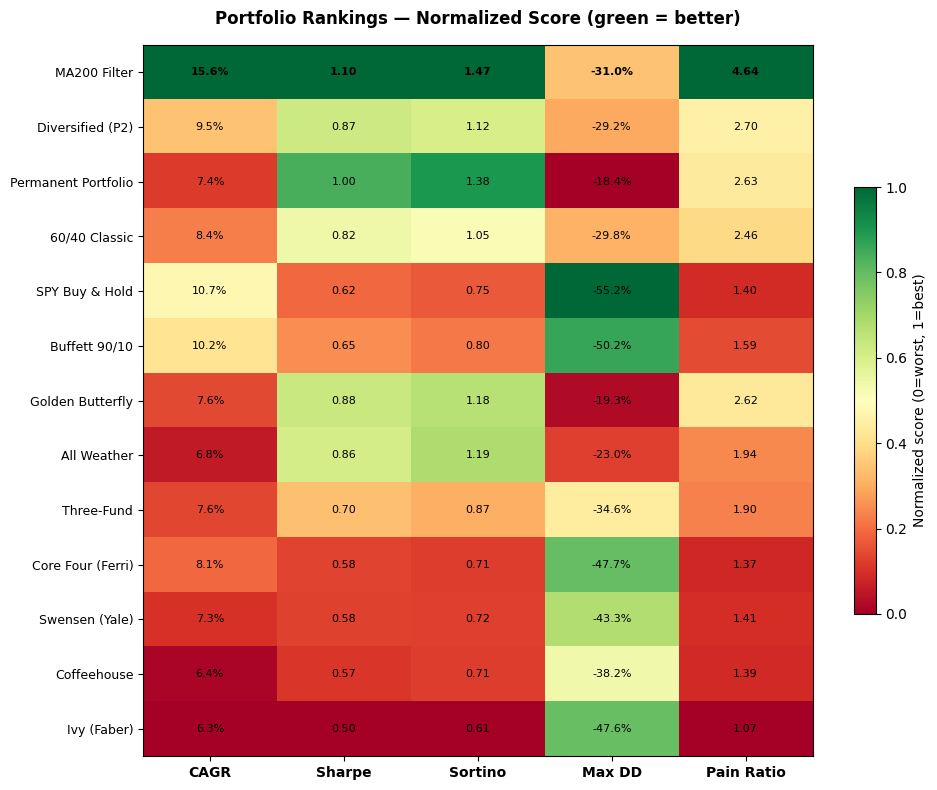

✓ Saved: outputs/fig11_heatmap.png


In [ ]:
# ── Robustness heatmap ─────────────────────────────────────────────
import matplotlib.colors as mcolors


# Rank each portfolio on 5 key metrics (higher rank = better)
rank_cols = {
    "CAGR"         : True,   # higher is better
    "Sharpe"       : True,
    "Sortino"      : True,
    "Max DD"       : False,  # less negative is better
    "Pain Ratio"   : True,
}

heat_df = metrics_full[list(rank_cols.keys())].copy()

# Normalize each column 0-1 for heatmap
heat_norm = pd.DataFrame(index=heat_df.index)
for col, higher_better in rank_cols.items():
    col_min = heat_df[col].min()
    col_max = heat_df[col].max()
    if higher_better:
        heat_norm[col] = (heat_df[col] - col_min) / (col_max - col_min)
    else:
        heat_norm[col] = (col_max - heat_df[col]) / (col_max - col_min)

# Sort by mean score
heat_norm["Score"] = heat_norm.mean(axis=1)
heat_norm = heat_norm.sort_values("Score", ascending=False)
heat_plot = heat_norm.drop(columns="Score")

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(heat_plot.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(heat_plot.columns)))
ax.set_xticklabels(heat_plot.columns, fontsize=10, fontweight="bold")
ax.set_yticks(range(len(heat_plot.index)))
ax.set_yticklabels(heat_plot.index, fontsize=9)

# Annotate with raw values
for i, portfolio in enumerate(heat_plot.index):
    for j, col in enumerate(heat_plot.columns):
        raw = heat_df.loc[portfolio, col]
        if col in ["CAGR", "Max DD"]:
            txt = f"{raw:.1%}"
        else:
            txt = f"{raw:.2f}"
        ax.text(j, i, txt, ha="center", va="center", fontsize=8,
                color="black", fontweight="bold" if portfolio == "MA200 Filter" else "normal")

ax.set_title("Portfolio Rankings — Normalized Score (green = better)",
             fontsize=12, fontweight="bold", pad=15)

plt.colorbar(im, ax=ax, shrink=0.6, label="Normalized score (0=worst, 1=best)")
plt.tight_layout()
plt.savefig("../images/fig11_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: ../images/fig11_heatmap.png")

## 11. Limitations and Future Work

The findings in this notebook are robust within the tested sample, but several limitations
should be considered before drawing broader conclusions.

---

### What this analysis does not claim

- The MA200 Filter is not presented as a trading strategy or investment recommendation.
  It is a simple exposure-management rule used to isolate the effect of carry cost
  vs. protection in diversified portfolios.
- Results are in-sample. No walk-forward or out-of-sample validation was performed.
- Transaction costs, slippage, bid-ask spread, and tax drag are not modeled.
  With ~52 signals over 20 years (~2-3 per year), impact is likely small but not zero.

---

### Parameter sensitivity (MA window)

The 200-day window was chosen as the market standard. Results have not been
tested across alternative windows (100, 150, 250, 300 days) or EMA variants.
It is possible that MA200 benefits from parameter luck in this specific sample.
A robustness grid across window lengths is a natural extension.

---

### Cash return assumption

When the MA200 Filter is out of the market, cash earns zero return.
This is the most conservative assumption — any positive cash return
(T-bill, money market) would further favor the MA200 Filter.
The analysis understates, not overstates, its advantage.

---

### Stress episode detector sensitivity

Stress episodes are defined by the P1 algorithm (drawdown threshold + MA200 + recovery rule).
Results have not been tested with alternative detectors (VIX-based, recession proxies,
different drawdown thresholds). The carry cost finding in normal regimes is robust to
episode definition since it covers 84% of trading days regardless of how stress is defined.

---

### Sample period bias

The 2006–2026 sample includes four major stress events (GFC, COVID, 2022, 2025)
and a prolonged bull market. This environment is particularly favorable to
trend-following and exposure management. Pre-2000 data (Block A) provides
historical context but uses proxy series, not investable instruments.

---

### What would strengthen these findings

- MA window robustness grid (100–300 days)
- Transaction cost sensitivity (5–10 bps per trade)
- Bootstrap confidence intervals on Sharpe and CAGR differences
- Walk-forward validation (e.g., train 2006–2015, test 2015–2026)
- Cash return scenarios (0%, T-bill, SHY proxy)

## 12. Does Rebalancing Frequency Matter?

If the protection mechanism is exposure dilution rather than correlation,
then how often you rebalance should not materially change the result.

We test this directly by running the same Diversified portfolio
at three rebalancing frequencies — monthly, quarterly, and annually —
and comparing against a Fixed 60% SPY + 40% cash portfolio with no hedging assets.

If rebalancing frequency drives protection, the three variants should diverge in stress.
If exposure level drives protection, they should converge.

In [27]:
# ── Rebalancing frequency decomposition ────────────────────────────

assets      = list(DIVERSIFIED_WEIGHTS.keys())
weights_div = np.array(list(DIVERSIFIED_WEIGHTS.values()))
ret_b_aligned = ret_b[assets].reindex(portfolios.index).dropna()

def build_rebalanced_portfolio(ret_df, weights, rebal_freq):
    """
    Build portfolio with given rebalancing frequency.
    rebal_freq: 'A' = annual, 'Q' = quarterly, 'M' = monthly
    """
    # Get rebalancing dates
    if rebal_freq == 'A':
        rebal_dates = (
            ret_df.groupby(ret_df.index.year)
            .apply(lambda x: x.index[0])
            .values
        )
    elif rebal_freq == 'Q':
        rebal_dates = (
            ret_df.groupby([ret_df.index.year, ret_df.index.quarter])
            .apply(lambda x: x.index[0])
            .values
        )
    elif rebal_freq == 'M':
        rebal_dates = (
            ret_df.groupby([ret_df.index.year, ret_df.index.month])
            .apply(lambda x: x.index[0])
            .values
        )

    port_returns    = []
    current_weights = weights.copy()

    for date in ret_df.index:
        if date in rebal_dates:
            current_weights = weights.copy()

        daily_ret = (current_weights * ret_df.loc[date].values).sum()
        port_returns.append(daily_ret)

        current_weights = current_weights * (1 + ret_df.loc[date].values)
        current_weights = current_weights / current_weights.sum()

    return pd.Series(port_returns, index=ret_df.index)


# ── Build three rebalancing frequencies ──────────────────────────────────────
ret_div_annual    = build_rebalanced_portfolio(ret_b_aligned, weights_div, 'A')
ret_div_annual.name    = "Diversified — Annual"

ret_div_quarterly = build_rebalanced_portfolio(ret_b_aligned, weights_div, 'Q')
ret_div_quarterly.name = "Diversified — Quarterly"

ret_div_monthly   = build_rebalanced_portfolio(ret_b_aligned, weights_div, 'M')
ret_div_monthly.name   = "Diversified — Monthly"

# ── Fixed 60% SPY + 40% cash (no hedging assets, annual rebalance) ────────────
rebal_dates_cash = (
    portfolios
    .groupby(portfolios.index.year)
    .apply(lambda x: x.index[0])
    .values
)

cash_returns    = []
cash_weight_spy = 0.60

for date in portfolios.index:
    if date in rebal_dates_cash:
        cash_weight_spy = 0.60
    daily_ret = cash_weight_spy * ret_b["SPY"].loc[date]
    cash_returns.append(daily_ret)
    spy_val         = cash_weight_spy * (1 + ret_b["SPY"].loc[date])
    cash_val        = (1 - cash_weight_spy)
    total           = spy_val + cash_val
    cash_weight_spy = spy_val / total

ret_cash = pd.Series(cash_returns, index=portfolios.index, name="Fixed 60% SPY + 40% cash")

# ── Combine ───────────────────────────────────────────────────────────────────
decomp = pd.DataFrame({
    "Diversified — Annual"    : ret_div_annual,
    "Diversified — Quarterly" : ret_div_quarterly,
    "Diversified — Monthly"   : ret_div_monthly,
    "Fixed 60% SPY + 40% cash": ret_cash,
}).dropna()

# ── Full metrics ──────────────────────────────────────────────────────────────
decomp_metrics = pd.DataFrame([
    full_metrics(decomp[col], col) for col in decomp.columns
]).set_index("Portfolio")

fmt = {
    "CAGR"         : "{:.2%}",
    "Volatility"   : "{:.2%}",
    "Sharpe"       : "{:.2f}",
    "Sortino"      : "{:.2f}",
    "Max DD"       : "{:.2%}",
    "Pain Ratio"   : "{:.2f}",
    "Recovery Days": "{:.0f}",
}
fmtfn = {k: (lambda x, f=v: f.format(x)) for k, v in fmt.items()}

print("── Rebalancing frequency — full period ────────────────────")
print(decomp_metrics.to_string(formatters=fmtfn))

# ── Regime breakdown ──────────────────────────────────────────────────────────
fmt2 = {
    "Days"                      : "{:.0f}",
    "Cum Return"                : "{:.2%}",
    "Ann. Return (regime days)" : "{:.2%}",
    "Volatility"                : "{:.2%}",
    "Sharpe"                    : "{:.2f}",
    "Max DD"                    : "{:.2%}",
}
fmtfn2 = {k: (lambda x, f=v: f.format(x)) for k, v in fmt2.items()}

print()
print("── Normal regime ──────────────────────────────────────────")
decomp_normal = pd.DataFrame([
    regime_performance(decomp[col], normal_mask, col) for col in decomp.columns
]).set_index("Portfolio")
print(decomp_normal.to_string(formatters=fmtfn2))

print()
print("── Stress episodes ────────────────────────────────────────")
decomp_stress = pd.DataFrame([
    regime_performance(decomp[col], stress_mask, col) for col in decomp.columns
]).set_index("Portfolio")
print(decomp_stress.to_string(formatters=fmtfn2))

── Rebalancing frequency — full period ────────────────────
                          CAGR Volatility Sharpe Sortino  Max DD Pain Ratio Recovery Days
Portfolio                                                                                
Diversified — Annual     9.46%     11.06%   0.87    1.12 -29.20%       2.70           311
Diversified — Quarterly  9.38%     11.33%   0.85    1.08 -31.13%       2.57           401
Diversified — Monthly    9.24%     11.47%   0.83    1.05 -32.02%       2.49           410
Fixed 60% SPY + 40% cash 6.81%     11.28%   0.64    0.79 -36.07%       1.57          1066

── Normal regime ──────────────────────────────────────────
                         Days Cum Return Ann. Return (regime days) Volatility Sharpe  Max DD
Portfolio                                                                                   
Diversified — Annual     4085    314.63%                     9.17%      8.77%   1.04 -20.02%
Diversified — Quarterly  4085    307.32%                    

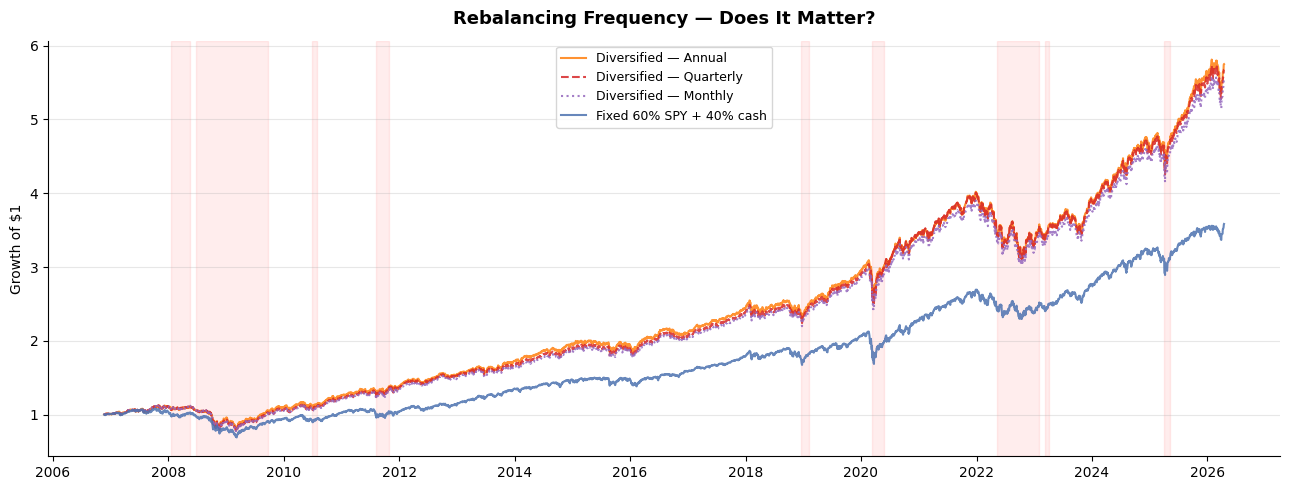

✓ Saved: outputs/fig12_rebalancing_frequency.png


In [ ]:
# ── Rebalancing frequency — equity curves ──────────────────────────

cum_decomp = (1 + decomp).cumprod()

fig, ax = plt.subplots(figsize=(13, 5))

colors = {
    "Diversified — Annual"    : "#FF7F0E",
    "Diversified — Quarterly" : "#D62728",
    "Diversified — Monthly"   : "#9467BD",
    "Fixed 60% SPY + 40% cash": "#4C72B0",
}
styles = {
    "Diversified — Annual"    : "-",
    "Diversified — Quarterly" : "--",
    "Diversified — Monthly"   : ":",
    "Fixed 60% SPY + 40% cash": "-",
}

for col in decomp.columns:
    ax.plot(cum_decomp.index, cum_decomp[col],
            color=colors[col], linestyle=styles[col],
            linewidth=1.5, label=col, alpha=0.85)

for s, e in episodes_b:
    ax.axvspan(s, e, color="red", alpha=0.07)

ax.set_title("Rebalancing Frequency — Does It Matter?",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Growth of $1", fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.savefig("../images/fig12_rebalancing_frequency.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: ../images/fig12_rebalancing_frequency.png")

## 13. Conclusions

**Finding 1 — Diversification has a permanent carry cost.**  
In normal regimes (83.9% of all trading days), the Diversified portfolio returned 2.8x vs 8.5x for the MA200 Filter and 4.3x for SPY Buy & Hold. The hedging assets drag returns every day markets are calm — and markets are calm most of the time.

**Finding 2 — The protection delivered is inconsistent and replaceable.**  
In stress episodes, the Diversified portfolio's max drawdown (-25.1%) was nearly identical to the MA200 Filter (-26.0%). The MA200 Filter achieved equivalent protection through exposure reduction, not asset correlation — making it robust to correlation regime changes.

**Finding 3 — 2022 broke the core assumption.**  
The negative SPX/Treasury correlation that sustains the 60/40 construct is a regime, not a law. It held from 2000 to 2021. Pre-2000, the correlation was persistently positive. In 2022, it turned positive again — and the Diversified portfolio lost -13.9% while the MA200 Filter lost -8.6%.

**Finding 4 — The trade-off does not exist.**  
Traditional diversification is not a return-for-protection exchange. It is a return sacrifice for protection that is regime-dependent, historically contingent, and replicable by a simpler rule with no carry cost in normal regimes.

---
*Project 3 will examine why this happens structurally: all traditional assets are variations of the same payoff — short volatility. The only genuine diversifier is positive convexity.*